### 0. Import Library

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from scipy import stats

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score, classification_report, accuracy_score, confusion_matrix, roc_auc_score

### 1. Load & Split Dataset 

In [131]:
input_path = "../../dataset/dataset.csv"
train_path = "../../dataset/train.csv"
test_path = "../../dataset/test.csv"

df = pd.read_csv(input_path)

# Split dataset (Ratio 70:30)
train_df, test_df = train_test_split(df, test_size=0.7, random_state=42)

# 4. Simpan hasil ke folder dataset
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Berhasil! Train set: {len(train_df)} baris, Test set: {len(test_df)} baris.")

Berhasil! Train set: 3000 baris, Test set: 7000 baris.


### 2. Exploratory Data Analisis

#### 2.1. Gambaran Umum Dataset

In [132]:
train_df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
5525,6.510693,2,Tier 3,UK,100-300,5,56.597317,80.059952,AI/ML,Consulting,3.725742,Not Placed
771,6.550027,0,Tier 2,UK,300+,2,81.902434,80.007429,Cloud,Healthcare,3.848416,Placed
7839,6.710621,1,Tier 2,UK,100-300,2,77.773190,73.650951,Data Science,Healthcare,3.091842,Placed
2395,5.840284,3,Tier 3,Germany,Top 100,2,86.235761,65.776400,Data Science,Healthcare,1.690939,Not Placed
1478,6.290006,0,Tier 2,UK,300+,1,64.651314,67.780671,AI/ML,Healthcare,6.718113,Not Placed


In [133]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 3000 entries, 5525 to 7270
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      3000 non-null   float64
 1   backlogs                  3000 non-null   int64  
 2   college_tier              3000 non-null   str    
 3   country                   3000 non-null   str    
 4   university_ranking_band   3000 non-null   str    
 5   internship_count          3000 non-null   int64  
 6   aptitude_score            3000 non-null   float64
 7   communication_score       3000 non-null   float64
 8   specialization            3000 non-null   str    
 9   industry                  3000 non-null   str    
 10  internship_quality_score  3000 non-null   float64
 11  placement_status          3000 non-null   str    
dtypes: float64(4), int64(2), str(6)
memory usage: 304.7 KB


In [134]:
train_df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,3000.000000,3000.000000,3000,3000,3000,3000.000000,3000.000000,3000.000000,3000,3000,3000.000000,3000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,USA,300+,NaN,NaN,NaN,Core CS,Consulting,NaN,Placed
freq,NaN,NaN,1197,621,1217,NaN,NaN,NaN,627,559,NaN,1836
mean,6.994145,1.263000,NaN,NaN,NaN,1.473333,70.098241,65.002925,NaN,NaN,5.032209,NaN
std,0.804845,1.159431,NaN,NaN,NaN,1.202125,14.902939,14.674932,NaN,NaN,1.525128,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.000000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.469739,0.000000,NaN,NaN,NaN,1.000000,60.163030,54.895301,NaN,NaN,4.007756,NaN
50%,6.985889,1.000000,NaN,NaN,NaN,1.000000,70.168721,64.705483,NaN,NaN,5.009967,NaN
75%,7.542350,2.000000,NaN,NaN,NaN,2.000000,80.567596,75.010740,NaN,NaN,6.025265,NaN


In [135]:
# Cek missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [136]:
 # Distribusi kelas target
print(train_df['placement_status'].value_counts())
print(train_df['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        1836
Not Placed    1164
Name: count, dtype: int64
placement_status
Placed        0.612
Not Placed    0.388
Name: proportion, dtype: float64


#### 2.2. Visualisasi 

##### 2.2.1. Visualisasi Proporsi Dataset

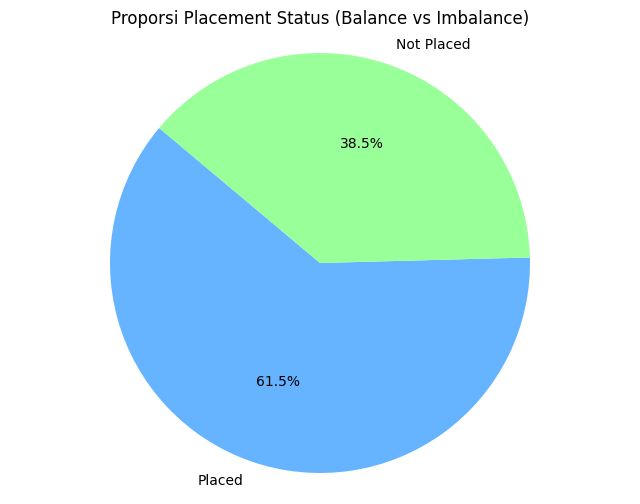

In [137]:
plt.figure(figsize=(8, 6))
# Menghitung distribusi kelas pada placement_status
placement_counts = df['placement_status'].value_counts()
plt.pie(placement_counts, labels=placement_counts.index, autopct='%1.1f%%', 
        colors=['#66b3ff','#99ff99'], startangle=140)
plt.title('Proporsi Placement Status (Balance vs Imbalance)')
plt.axis('equal') 
plt.show()

##### 2.2.2. Visualisasi Identifikasi Outlier pada Tiap Kolom

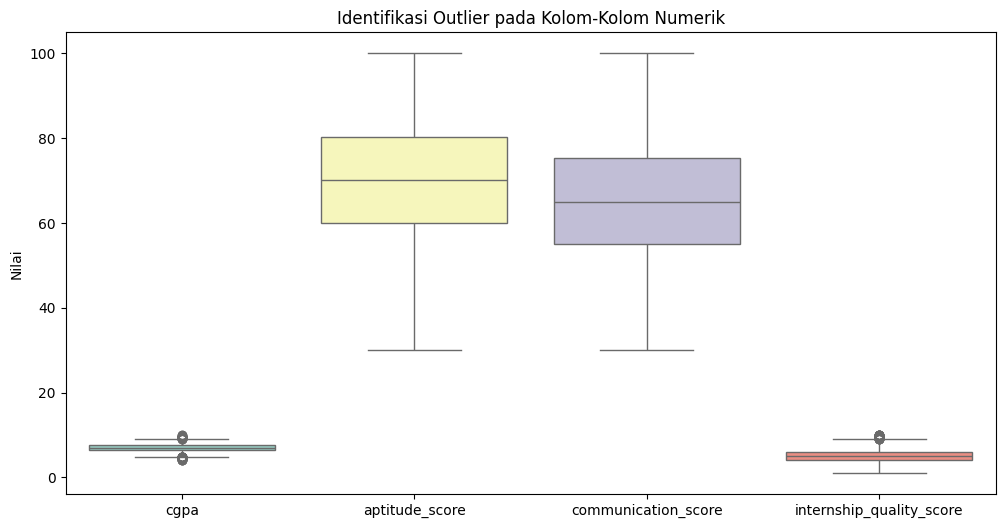

In [138]:
plt.figure(figsize=(12, 6))
# Memilih variabel numerik utama untuk melihat outlier menggunakan Boxplot
numerical_cols = ['cgpa', 'aptitude_score', 'communication_score', 'internship_quality_score']
sns.boxplot(data=df[numerical_cols], palette='Set3')
plt.title('Identifikasi Outlier pada Kolom-Kolom Numerik')
plt.ylabel('Nilai')
plt.show()

##### 2.2.3. Visualisasi Korelasi Kolom Kategorikal dengan Kelas Target

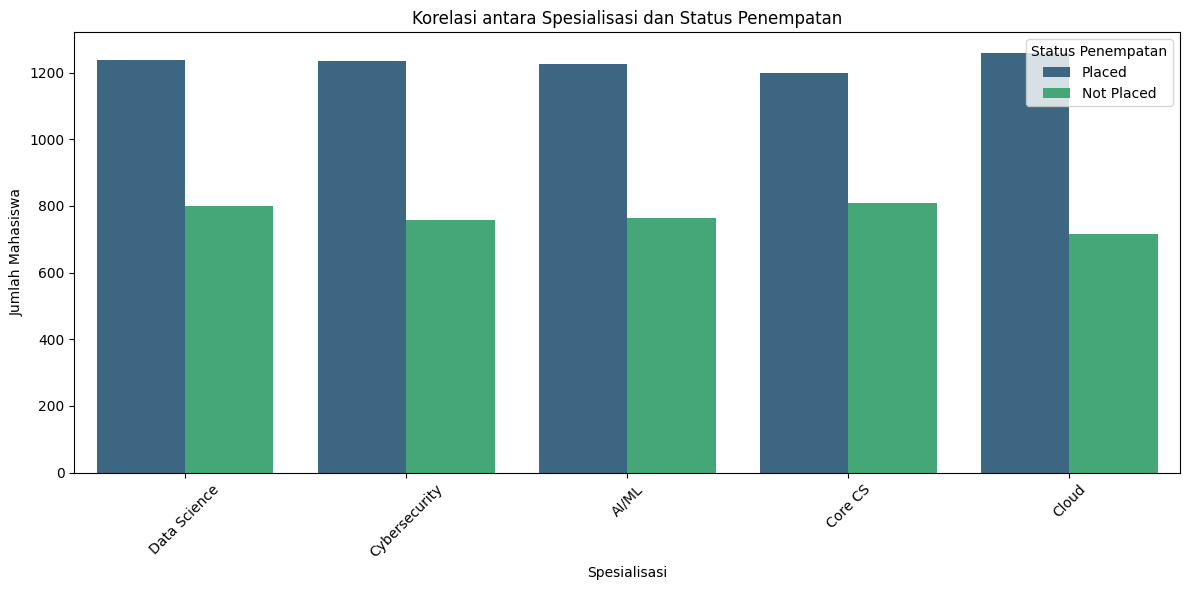

In [139]:
plt.figure(figsize=(12, 6))
# Melihat hubungan antara 'specialization' dengan target 'placement_status'
sns.countplot(x='specialization', hue='placement_status', data=df, palette='viridis')
plt.title('Korelasi antara Spesialisasi dan Status Penempatan')
plt.xlabel('Spesialisasi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=45)
plt.legend(title='Status Penempatan')
plt.tight_layout()
plt.show()

### 3. Data Cleaning & Preprocessing

In [140]:
TARGET_COL = 'placement_status'
ID_COL     = None 

# Mengambil kolom dengan tipe data 'object' sebagai kategorikal
CAT_COLS = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']

# Mengambil sisa kolom sebagai numerik
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + [TARGET_COL] + ([ID_COL] if ID_COL else [])]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

# Buat salinan sesuai referensi
train = train_df.copy()
test  = test_df.copy()

print(f"\nData berhasil dipisahkan:")
print(f"Jumlah baris Data Train: {len(train)}")
print(f"Jumlah baris Data Test : {len(test)}")

Categorical: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']

Data berhasil dipisahkan:
Jumlah baris Data Train: 3000
Jumlah baris Data Test : 7000


#### 3.1. Handling Missing Value 

In [141]:
print(f"Otomatis mendeteksi: {len(NUM_COLS)} kolom Numerik dan {len(CAT_COLS)} kolom Kategorikal.")

if NUM_COLS:
    num_imputer = SimpleImputer(strategy='median')
    train[NUM_COLS] = num_imputer.fit_transform(train[NUM_COLS])
    test[NUM_COLS]  = num_imputer.transform(test[NUM_COLS])
    print("Imputasi Numerik (Median) selesai.")

if CAT_COLS:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    train[CAT_COLS] = cat_imputer.fit_transform(train[CAT_COLS])
    test[CAT_COLS]  = cat_imputer.transform(test[CAT_COLS])
    print("Imputasi Kategorikal (Modus) selesai.")

print(f"Missing values di Train: {train.isnull().sum().sum()}")

Otomatis mendeteksi: 6 kolom Numerik dan 5 kolom Kategorikal.
Imputasi Numerik (Median) selesai.
Imputasi Kategorikal (Modus) selesai.
Missing values di Train: 0


#### 3.2. Handling Outliers

In [142]:
outlier_summary = {}

# Metode 1: IQR dengan Clipping (digunakan dalam praktik)
for col in NUM_COLS:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
    outlier_summary[col] = {'outliers_detected': outliers_count, 'lower': lower_bound, 'upper': upper_bound}
    
    print(f" - {col:30s}: {outliers_count:3d} outlier (bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")

    # Clipping data train dan test menggunakan bound dari train
    train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
    test[col] = test[col].clip(lower=lower_bound, upper=upper_bound)


 - cgpa                          :  22 outlier (bounds: [4.86, 9.15])
 - backlogs                      :  12 outlier (bounds: [-3.00, 5.00])
 - internship_count              : 187 outlier (bounds: [-0.50, 3.50])
 - aptitude_score                :   0 outlier (bounds: [29.56, 111.17])
 - communication_score           :   0 outlier (bounds: [24.72, 105.18])
 - internship_quality_score      :  15 outlier (bounds: [0.98, 9.05])


#### 3.3. Encode Fitur Kategorikal

In [143]:
train = pd.get_dummies(train, columns=CAT_COLS, drop_first=True)
test = pd.get_dummies(test, columns=CAT_COLS, drop_first=True)

valid_cols = [c for c in train.columns if c != ID_COL]
test = test.reindex(columns=valid_cols, fill_value=0)

#### 3.4. Feature Scalling 

In [144]:
scaler = StandardScaler()

# Fit pada training data SAJA - avoid data leakage
train[NUM_COLS] = scaler.fit_transform(train[NUM_COLS])
# Transform test data menggunakan parameter yang sudah fitted
test[NUM_COLS] = scaler.transform(test[NUM_COLS])

#### 3.5. Feature Engineering

In [145]:
def create_features(df):
    df['total_assessment_score'] = df['aptitude_score'] + df['communication_score']

    # Menghitung bobot pengalaman magang (kuantitas x kualitas)
    df['internship_experience_index'] = df['internship_count'] * df['internship_quality_score']

    # Rasio kegagalan (backlog) terhadap IPK. 
    # Ditambah 1 pada penyebut untuk menghindari pembagian dengan nol.
    df['academic_risk_ratio'] = df['backlogs'] / (df['cgpa'] + 1)

    # Rata-rata dari semua nilai tes yang tersedia
    df['average_test_score'] = df[['aptitude_score', 'communication_score', 'internship_quality_score']].mean(axis=1)

    # Menandai mahasiswa yang punya CGPA > 8.0 DAN tidak punya backlog
    df['is_high_achiever'] = ((df['cgpa'] > 8.0) & (df['backlogs'] == 0)).astype(int)

    # Interaksi antara Aptitude dan CGPA (mengasumsikan kecerdasan akademik berkorelasi dengan logika)
    df['technical_power'] = df['aptitude_score'] * df['cgpa']
    print("Fitur baru berhasil ditambahkan!")
    print(df[['total_assessment_score', 'internship_experience_index', 'academic_risk_ratio', 'is_high_achiever']].head())
    return df

train = create_features(train)
test = create_features(test)

Fitur baru berhasil ditambahkan!
      total_assessment_score  internship_experience_index  \
5525                0.120134                    -1.642338   
771                 1.814832                    -0.413586   
7839                1.104486                    -0.678463   
2395                1.135738                    -1.168920   
1478               -0.176238                    -0.432447   

      academic_risk_ratio  is_high_achiever  
5525             1.640039                 0  
771             -2.477717                 0  
7839            -0.350930                 0  
2395            -3.427509                 0  
1478            -9.265520                 0  
Fitur baru berhasil ditambahkan!
      total_assessment_score  internship_experience_index  \
6252                1.840162                     0.253132   
4684                0.143648                    -0.306792   
1731               -1.431381                    -1.774729   
4742                3.271253                   

### 4. Model & Validation
#### 4.1. Model FFNN Scikit

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# TARGET ENCODING - KONVERSI KATEGORIKAL KE NUMERIK
if train[TARGET_COL].dtype == 'object':
    train[TARGET_COL] = train[TARGET_COL].map({'Placed': 1, 'Not Placed': 0})
    test[TARGET_COL] = test[TARGET_COL].map({'Placed': 1, 'Not Placed': 0})

# PERSIAPAN DATA - AVOID DATA LEAKAGE
X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]

X_test = test.drop(columns=[TARGET_COL])
y_test = test[TARGET_COL]

if ID_COL and ID_COL in X_train.columns:
    X_train = X_train.drop(columns=[ID_COL])
    X_test = X_test.drop(columns=[ID_COL])


print("\n" + "="*70)
print("HYPERPARAMETER TUNING KOMPREHENSIF")
print("="*70)

# Macro F1 Scorer
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix
macro_f1_scorer = make_scorer(f1_score, average='macro')

hidden_layer_configs = [
    (32,),   # Narrow
    (64,),   # Medium
    (128,),  # Wide
    
    (64, 32),    # 2-layer decreasing
    (32, 32),    # 2-layer same width
    (128, 64),   # 2-layer wide decreasing
    
    (128, 64, 32),   # 3-layer decreasing
    (64, 64, 64),    # 3-layer same width
    (96, 48, 24),    # 3-layer with reduction
]

# 2. ACTIVATION FUNCTIONS (excluding 'identity' untuk stabilitas)
activations = ['relu', 'tanh', 'logistic']

# 3. LEARNING RATES
learning_rates = [0.0001, 0.001, 0.01]

# 4. REGULARIZATION (L2 PENALTY - Alpha)
alphas = [0.00001, 0.0001, 0.001, 0.01]

# Create comprehensive parameter grid
param_grid = {
    'hidden_layer_sizes': hidden_layer_configs,
    'activation': activations,
    'learning_rate_init': learning_rates,
    'alpha': alphas,
}

mlp = MLPClassifier(
    max_iter=1000,           # Increased max iterations
    random_state=42,
    solver='adam',           # Use adam optimizer untuk stabilitas
    batch_size=32,           # Mini-batch size
    tol=1e-4,                # Tolerance for optimization
    verbose=0
)

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring=macro_f1_scorer,
    cv=3,           # 3-Fold Cross Validation
    n_jobs=-1,      # Use all CPU cores
    verbose=1,      # Print progress
    return_train_score=True  # Track training scores
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score_cv = grid_search.best_score_
best_model = grid_search.best_estimator_

print("HASIL TUNING - BEST PARAMETERS")
print(f"\nBest Macro F1-Score: {best_score_cv:.4f}")
print(f"\nHyperparameter Terbaik:")
for param_name, param_value in best_params.items():
    print(f"  {param_name:25s} = {param_value}")



HYPERPARAMETER TUNING KOMPREHENSIF
Fitting 3 folds for each of 324 candidates, totalling 972 fits


PERFORMA MODEL PADA TRAIN SET
Train Accuracy:     0.7900
Train Macro F1:     0.7730

PERFORMA MODEL PADA TEST SET (FINAL)
Test Accuracy:      0.7413
Test Macro F1:      0.7211

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

  Not Placed     0.6791    0.6161    0.6461      2683
      Placed     0.7744    0.8191    0.7961      4317

    accuracy                         0.7413      7000
   macro avg     0.7268    0.7176    0.7211      7000
weighted avg     0.7379    0.7413    0.7386      7000


CONFUSION MATRIX (TEST SET)
True Negatives:  1653
False Positives: 1030
False Negatives: 781
True Positives:  3536


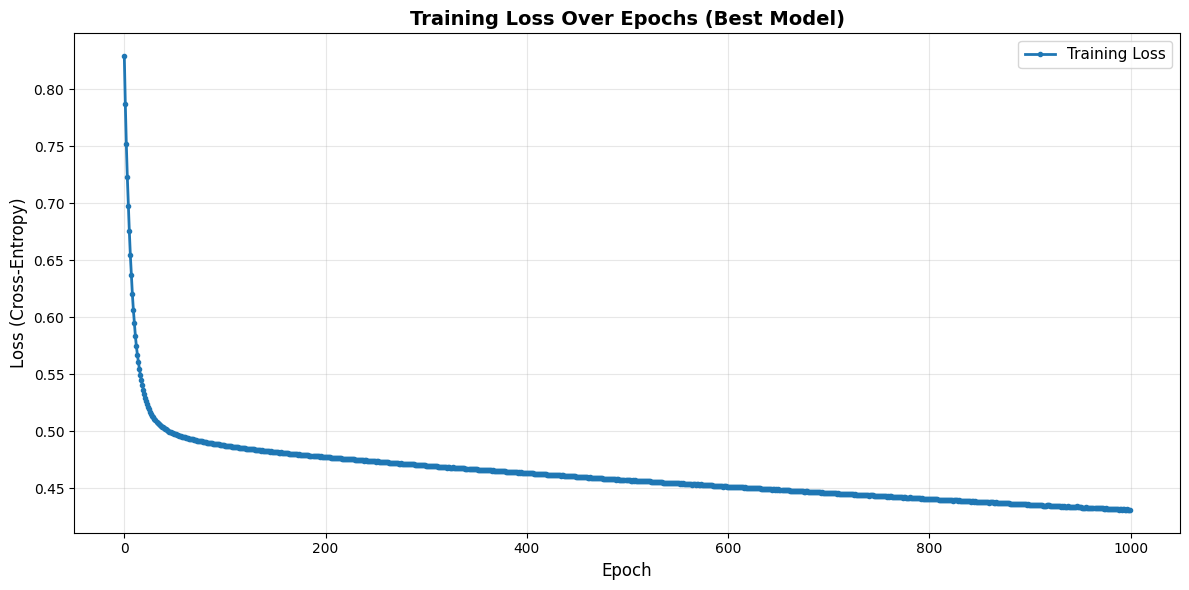


LOSS CURVE INSIGHTS
Minimum Loss: 0.431009 at Epoch 998
Initial Loss: 0.828914
Final Loss:   0.431214
Total Epochs: 1000

MODEL ARCHITECTURE & WEIGHTS INFO
Input Features: 29
Hidden Layers: (32,)
Number of Layers: 2
Output Classes: 1

Top 10 Feature Importance (berdasarkan first layer weight magnitude):
   1. industry_Finance                         : 0.3404
   2. specialization_Cybersecurity             : 0.3070
   3. industry_Healthcare                      : 0.2981
   4. specialization_Cloud                     : 0.2975
   5. country_USA                              : 0.2963
   6. industry_Tech                            : 0.2962
   7. industry_Other                           : 0.2781
   8. country_India                            : 0.2779
   9. country_UK                               : 0.2772
  10. internship_count                         : 0.2489

SUMMARY & KEY FINDINGS
✓ Best Configuration Found:
  - Hidden Layers: (32,)
  - Activation: relu
  - Learning Rate: 0.0001
  - L2 Reg

In [ ]:
# PREDIKSI PADA TRAIN SET
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_macro_f1 = f1_score(y_train, y_pred_train, average='macro')
test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("AKURASI MODEL PADA TRAIN SET")
print(f"Train Accuracy:     {train_accuracy:.4f}")
print(f"Train Macro F1:     {train_macro_f1:.4f}")

print("AKURASI MODEL PADA TEST SET (FINAL)")
print(f"Test Accuracy:      {test_accuracy:.4f}")
print(f"Test Macro F1:      {test_macro_f1:.4f}")

print("HASIL KLASIFIKASI (TEST SET)")
print(classification_report(y_test, y_pred_test, 
                          target_names=['Not Placed', 'Placed'],
                          digits=4))

# Deteksi overfitting/underfitting
if train_macro_f1 - test_macro_f1 > 0.05:
    print(f"\n⚠ Warning: Potential Overfitting detected (Train F1: {train_macro_f1:.4f} >> Test F1: {test_macro_f1:.4f})")
elif test_macro_f1 - train_macro_f1 > 0.05:
    print(f"\n⚠ Warning: Potential Underfitting detected (Test F1: {test_macro_f1:.4f} >> Train F1: {train_macro_f1:.4f})")
else:
    print(f"\n✓ Generalization: Model shows good generalization (Diff: {abs(train_macro_f1 - test_macro_f1):.4f})")


In [ ]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_test)
print("\n" + "="*70)
print("CONFUSION MATRIX (TEST SET)")
print("="*70)
print(f"True Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

In [ ]:
# Extract loss curve dari best model
loss_curve = best_model.loss_curve_

# Buat plot loss curve
plt.figure(figsize=(12, 6))
plt.plot(loss_curve, linewidth=2, marker='o', markersize=3, label='Training Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.title('Training Loss Over Epochs (Best Model)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

min_loss = min(loss_curve)
min_loss_epoch = np.argmin(loss_curve)
print(f"\n" + "="*70)
print("LOSS CURVE INSIGHTS")
print("="*70)
print(f"Minimum Loss: {min_loss:.6f} at Epoch {min_loss_epoch + 1}")
print(f"Initial Loss: {loss_curve[0]:.6f}")
print(f"Final Loss:   {loss_curve[-1]:.6f}")
print(f"Total Epochs: {len(loss_curve)}")